# 07 하남교산 설치 우선순위 산출 (2순위)

**목표**: 유사_고위험 격자 + 토지 파생변수로 하남교산 스마트 시설 설치 우선순위 도출.

- 입력: `하남교산_유사격자_매칭.csv`, `격자_토지이용_파생변수_하남교산.csv`
- 산출: `하남교산_설치우선순위_격자.csv`

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

cwd = os.getcwd()
candidates = ['../data/', '../../data/', 'data/', '1최종_LH/data/']
data_path = None
for p in candidates:
    probe = os.path.join(p, '통합_데이터')
    if os.path.exists(probe):
        data_path = p
        break
if data_path is None:
    data_path = '1최종_LH/data/'
out = os.path.join(data_path, '통합_데이터')
print('data_path:', data_path)

data_path: ../../data/


## 1. 데이터 로드·merge

In [2]:
def load_csv(path, enc=('utf-8','utf-8-sig','cp949')):
    for e in enc:
        try: return pd.read_csv(path, encoding=e)
        except: continue
    raise ValueError('로드 실패: ' + path)

유사 = load_csv(os.path.join(out, '하남교산_유사격자_매칭.csv'))
토지 = load_csv(os.path.join(out, '격자_토지이용_파생변수_하남교산.csv'))

하남 = 유사.merge(토지, left_on='하남_gid', right_on='gid', how='left')
하남 = 하남.drop(columns=['gid'], errors='ignore')
하남 = 하남.rename(columns={'하남_gid': 'gid'})
print('하남교산 격자:', len(하남))
print('유사_고위험_여부=1:', 하남['유사_고위험_여부'].sum())

하남교산 격자: 770
유사_고위험_여부=1: 268


## 2. 우선순위 점수 산출

In [ ]:
# ── 우선순위 점수 산출 ────────────────────────────────────────────────────
# 점수 구성:
#   유사_고위험_여부 × 2  : 4시·구 고위험 격자와 토지 유사 → 위험 전이 가능성 (최우선)
#   도로_격자_여부        : 교통 발생 격자 여부
#   학교_비율 × 3         : 통학로 근접성 (미성년자 노출 핵심 지표)
#   유사도                : 코사인 유사도 → 매칭 신뢰도 보정
가중_학교 = 3
하남['우선순위_점수'] = (
    하남['유사_고위험_여부'] * 2 +
    하남['도로_격자_여부'] +
    (하남['학교_비율'] * 가중_학교).fillna(0) +
    하남['유사도'].fillna(0)
)

# ── Tie-breaking: 동점일 경우 도로_비율 → 주거_비율 순으로 내림차순 정렬 ──
# 도로_비율: 도로 면적이 많을수록 교통 노출 위험 ↑
# 주거_비율: 주거 비율이 높을수록 미성년자 거주 밀도 ↑
하남 = 하남.sort_values(
    ['우선순위_점수', '도로_비율', '주거_비율'],
    ascending=[False, False, False]
).reset_index(drop=True)
하남['우선순위_순위'] = range(1, len(하남)+1)

print('우선순위 상위 10:')
print(하남[['gid', '유사_고위험_여부', '도로_격자_여부', '학교_비율', '유사도', '도로_비율', '주거_비율', '우선순위_점수']].head(10))
print()
# 동점 분포 확인
동점_분포 = 하남.groupby('우선순위_점수').size().sort_index(ascending=False)
print('점수별 격자 수:')
for score, cnt in 동점_분포.items():
    print(f'  {score:.3f}점: {cnt:>4}개')

우선순위 상위 10:
        gid  유사_고위험_여부  도로_격자_여부  학교_비율  유사도  도로_비율  주거_비율  우선순위_점수
0  다사728464          1         1    0.0  1.0    0.5    0.0      4.0
1  다사728467          1         1    0.0  1.0    0.5    0.0      4.0
2  다사729474          1         1    0.0  1.0    0.5    0.0      4.0
3  다사736452          1         1    0.0  1.0    0.5    0.0      4.0
4  다사742466          1         1    0.0  1.0    0.5    0.0      4.0
5  다사744480          1         1    0.0  1.0    0.5    0.0      4.0
6  다사745483          1         1    0.0  1.0    0.5    0.0      4.0
7  다사745484          1         1    0.0  1.0    0.5    0.0      4.0
8  다사748479          1         1    0.0  1.0    0.5    0.0      4.0
9  다사750478          1         1    0.0  1.0    0.5    0.0      4.0

점수별 격자 수:
  4.000점:   36개
  4.000점:    4개
  4.000점:    3개
  3.999점:    1개
  3.999점:    7개
  3.996점:    1개
  3.995점:    4개
  3.990점:    1개
  3.990점:    1개
  3.985점:    2개
  3.984점:    1개
  3.984점:    1개
  3.982점:    1개
  3.979점:    1개
  3.9

## 3. 저장

In [4]:
하남.to_csv(os.path.join(out, '하남교산_설치우선순위_격자.csv'), index=False, encoding='utf-8-sig')
print('저장:', out + '/하남교산_설치우선순위_격자.csv')
print('Top20 우선 설치 후보:', 하남.head(20)['gid'].tolist())

저장: ../../data/통합_데이터/하남교산_설치우선순위_격자.csv
Top20 우선 설치 후보: ['다사728464', '다사728467', '다사729474', '다사736452', '다사742466', '다사744480', '다사745483', '다사745484', '다사748479', '다사750478', '다사720443', '다사726451', '다사728440', '다사730439', '다사750480', '다사727466', '다사731472', '다사732474', '다사733478', '다사734478']


---
## [C-3] 하남교산 미성년자 유동 추정값

하남교산은 신도시 개발 예정지로 **실측 유동인구 데이터가 없음**.  
유사도 매칭으로 연결된 4시·구 격자의 `미성년자_유동` 값을 **대리 추정값**으로 전이.

> **전이 논리**: 토지 이용 구조가 유사한 격자는 개발 완료 후 유사한 유동 패턴을 보일 것으로 가정.  
> 이는 추정값(estimate)이며, 개발 계획 확정 후 실제 인구 데이터로 갱신해야 함.

=== 하남교산 미성년자 유동 추정값 ===
  유동_추정 > 0 격자: 760/770 (98.7%)
  유동_추정 평균:    74.77
  유동_추정 최댓값:  972.40

상위 5 격자 (유동 추정 높은 순):
     gid  우선순위_순위  미성년자_유동_추정      유사도  우선순위_점수
다사744477      529  972.405000 0.816750 1.816750
다사732473      139  614.270833 0.864536 3.864536
다사731478      238  614.270833 0.861550 2.861550
다사732478      239  614.270833 0.861550 2.861550
다사732479      240  614.270833 0.861550 2.861550


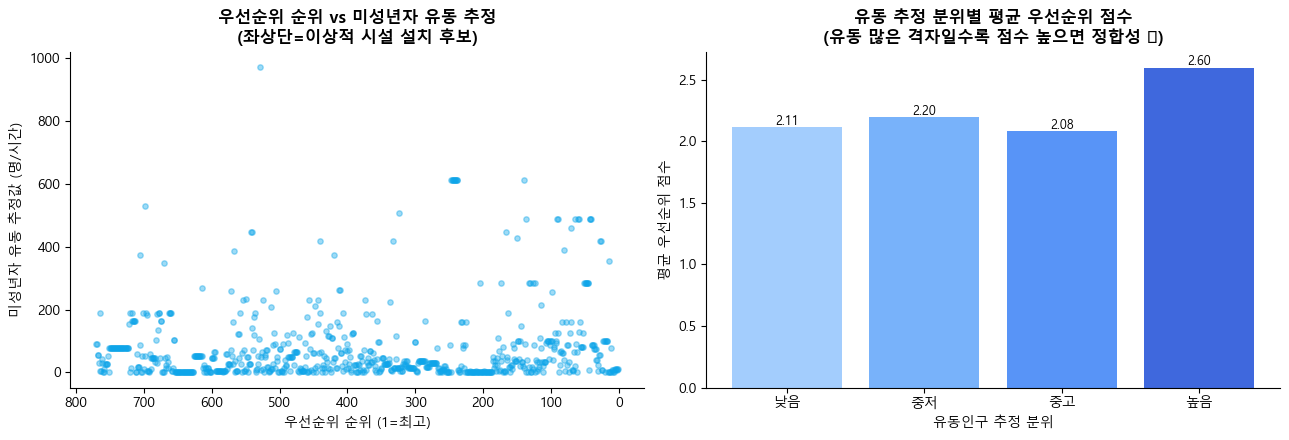


미성년자_유동_추정 컬럼 추가 후 재저장 완료


In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 격자_최종통합.csv에서 4시구 격자의 미성년자_유동 로드 ────────────────
통합_path = os.path.join(out, '격자_최종통합.csv')

if os.path.exists(통합_path):
    통합 = load_csv(통합_path)
    if '미성년자_유동' in 통합.columns:
        유동_map = 통합.set_index('gid')['미성년자_유동'].to_dict()

        # 유사도 매칭된 4시구 gid의 유동값 → 하남교산 추정값으로 전이
        하남['미성년자_유동_추정'] = 하남['유사_4시구_gid'].map(유동_map).fillna(0)

        print('=== 하남교산 미성년자 유동 추정값 ===')
        print(f'  유동_추정 > 0 격자: {(하남["미성년자_유동_추정"]>0).sum():,}/{len(하남):,} ({(하남["미성년자_유동_추정"]>0).mean()*100:.1f}%)')
        print(f'  유동_추정 평균:    {하남["미성년자_유동_추정"].mean():.2f}')
        print(f'  유동_추정 최댓값:  {하남["미성년자_유동_추정"].max():.2f}')
        print()
        print('상위 5 격자 (유동 추정 높은 순):')
        top5 = 하남.nlargest(5, '미성년자_유동_추정')[['gid','우선순위_순위','미성년자_유동_추정','유사도','우선순위_점수']]
        print(top5.to_string(index=False))

        # 시각화: 우선순위 순위 vs 유동 추정값
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        ax = axes[0]
        ax.scatter(하남['우선순위_순위'], 하남['미성년자_유동_추정'],
                   alpha=0.4, s=15, color='#0ea5e9')
        ax.set_xlabel('우선순위 순위 (1=최고)')
        ax.set_ylabel('미성년자 유동 추정값 (명/시간)')
        ax.set_title('우선순위 순위 vs 미성년자 유동 추정\n(좌상단=이상적 시설 설치 후보)', fontweight='bold')
        ax.invert_xaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax2 = axes[1]
        유동_분위 = pd.qcut(하남['미성년자_유동_추정'].clip(lower=0) + 1e-9, q=4,
                           labels=['낮음', '중저', '중고', '높음'], duplicates='drop')
        분위별_점수 = 하남.groupby(유동_분위, observed=True)['우선순위_점수'].mean()
        bars = ax2.bar(분위별_점수.index, 분위별_점수.values,
                       color=['#93c5fd','#60a5fa','#3b82f6','#1d4ed8'], alpha=0.85)
        ax2.set_title('유동 추정 분위별 평균 우선순위 점수\n(유동 많은 격자일수록 점수 높으면 정합성 ✅)', fontweight='bold')
        ax2.set_xlabel('유동인구 추정 분위')
        ax2.set_ylabel('평균 우선순위 점수')
        for bar in bars:
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{bar.get_height():.2f}', ha='center', fontsize=9)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()

        # 추정값 포함해 저장
        하남.to_csv(os.path.join(out, '하남교산_설치우선순위_격자.csv'), index=False, encoding='utf-8-sig')
        print('\n미성년자_유동_추정 컬럼 추가 후 재저장 완료')
    else:
        print('⚠ 격자_최종통합.csv에 미성년자_유동 컬럼 없음 → 01_API_격자_연동 재실행 필요')
else:
    print('⚠ 격자_최종통합.csv 없음 → 01_API_격자_연동 실행 후 재시도')